In [1]:
import util
import processUtil

from skimage import filters, morphology, measure, exposure
from skimage.segmentation import find_boundaries
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import joblib

# Get data

In [2]:
file_path = "processed_data/aliveData.joblib"

if os.path.exists(file_path):
    data = joblib.load(file_path)
else:
    data = util.getAliveData()
    joblib.dump(data, file_path)

# Get Mask (Segmentation)

In [3]:
# get masks and corrects for all alive data
# masks_corrected: index 0 = mask, index 1 = corrected
file_path = "processed_data/maskCorrect.joblib"

if os.path.exists(file_path):
    masks_corrected = joblib.load(file_path)
else:
    masks_corrected = []
    for i in range(len(data)):
        masks_corrected.append(processUtil.getSegments(data[i]))
    joblib.dump(masks_corrected, file_path)

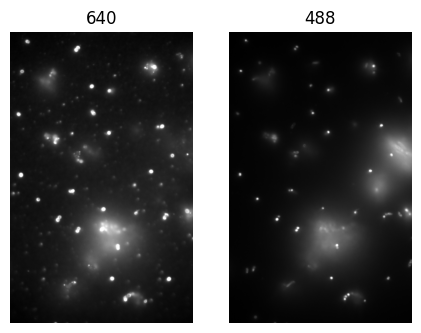

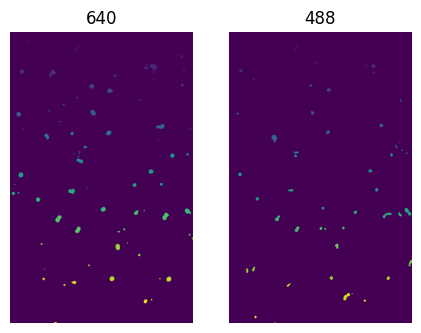

In [4]:
img_index = 133 # 0-133
util.printImg(data[img_index], "gray")
util.printMask(masks_corrected[img_index])

# Get Morphological Features

In [5]:
# get stats of each bateria for each img data
# stats: label, area, x, y, major_length, minor_length
file_path = "processed_data/maskSegmentStat.joblib"

if os.path.exists(file_path):
    stats = joblib.load(file_path)
else:
    stats = []
    for i in range(len(data)):
        stats.append(processUtil.getStats(masks_corrected[i], data[i]))
    joblib.dump(stats, file_path)

Image: pos_226


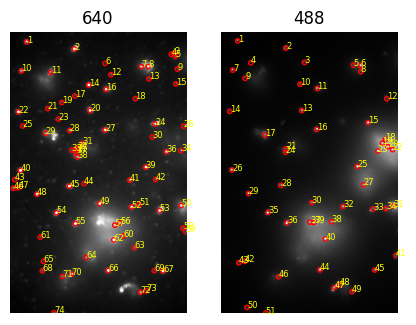

In [6]:
print(f"Image: {data[img_index][3]}")
util.printRegion(data[img_index], stats[img_index], map="gray")

In [7]:
print(stats[img_index][1])

    label   area           x           y  major_length  minor_length  \
0       1   38.0   39.421053   21.789474      8.328548      5.905849   
1       2   64.0  156.375000   39.140625     13.615157      6.427371   
2       3   25.0  201.640000   74.040000      9.923077      3.084372   
3       4    6.0   71.000000   75.166667      3.829708      1.885618   
4       5   17.0  320.705882   80.764706      5.848765      3.661203   
5       6   66.0  337.393939   81.712121      9.622454      8.743447   
6       7   39.0   27.282051   92.923077      7.534280      6.603839   
7       8   13.0  338.384615   96.615385      4.318667      3.679465   
8       9    9.0   57.111111  112.777778      4.312594      2.660929   
9      10   32.0  190.750000  127.187500      7.134661      5.790865   
10     11   62.0  232.854839  137.532258     10.256832      7.795266   
11     12   20.0  401.550000  162.300000      7.405734      3.416886   
12     13   52.0  195.019231  191.134615      9.714025      7.02

In [8]:
print(len(stats[img_index][0]))
print(len(stats[img_index][1]))

74
51


# Segmentation Comparison

In [9]:
file_path = "processed_data/compare.joblib"

if os.path.exists(file_path):
    compared = list(joblib.load(file_path))
else:
    compared = []
    for i in range(len(data)):
        shared, only_640, only_488, df_640_labeled, df_488_labeled, combined = processUtil.match_two_channels_greedy(
            df_a=stats[0][0],
            df_b=stats[0][1],
            tolerance=3,
            area_ratio_warning=3.0,
            channel_a_name="640",
            channel_b_name="488"
        )
        compared.append({"shared":shared, "only_640":only_640, "only_488":only_488, "df_640_labeled":df_640_labeled, "df_488_labeled":df_488_labeled, "combined":combined})
    joblib.dump(compared, file_path)

Image: pos_226


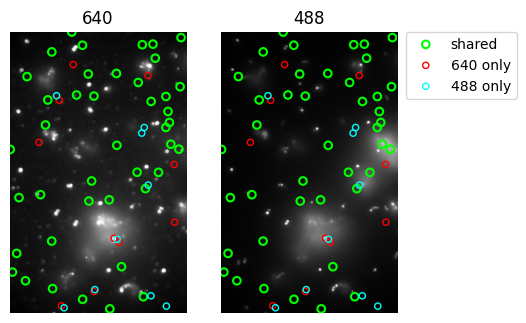

In [10]:
print(f"Image: {data[img_index][3]}")
util.printLabel(data[img_index], compared[img_index], map="gray")

Todo:
- count num of bateria:
```python
print(f"Segmentation complete.")
print(f"Masks shape: {masks.shape}")
print("Unique mask values:", np.unique(masks))
print("Number of objects:", len(np.unique(masks)) - 1)
```

Image: pos_53


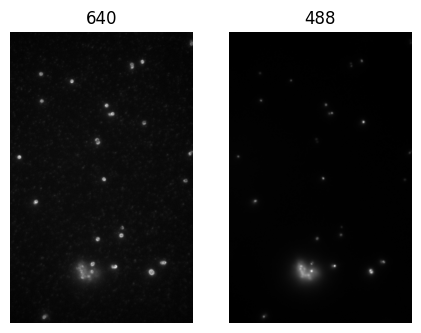

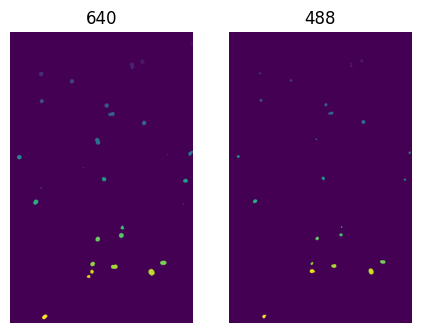

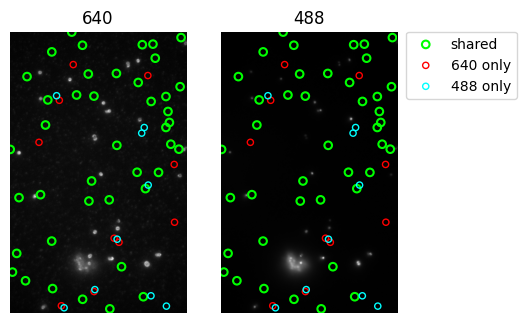

In [11]:
# testing
img_index = 10 # 0-133
print(f"Image: {data[img_index][3]}")
util.printImg(data[img_index], "gray")
util.printMask(masks_corrected[img_index])
util.printLabel(data[img_index], compared[img_index], map="gray")

In [12]:
print(compared[img_index]["combined"])

   object_class           x           y  640_label  488_label  in_640  in_488  \
0        shared  149.607143    0.863095        1.0        1.0    True    True   
1        shared  328.618197  381.252551       34.0       33.0    True    True   
2        shared  378.378325  232.637767       24.0       22.0    True    True   
3        shared    5.435846  584.099588       45.0       42.0    True    True   
4        shared   15.798282  538.639261       43.0       40.0    True    True   
..          ...         ...         ...        ...        ...     ...     ...   
56     488_only  259.866242  504.210191        NaN       38.0   False    True   
57     488_only  205.688073  626.660550        NaN       44.0   False    True   
58     488_only  342.052632  641.710526        NaN       46.0   False    True   
59     488_only  130.934524  670.809524        NaN       49.0   False    True   
60     488_only  379.571429  666.809524        NaN       50.0   False    True   

    distance  area_ratio  a